In [2]:
import pandas as pd

# Διαβάζουμε το αρχείο Excel
df = pd.read_excel("/content/Pre-term-labour-Data-ready-for-ml-pipeline_final.xlsx", engine="openpyxl")

# Εμφάνιση των πρώτων γραμμών
df.head()

,Maternal age,BW centile,UtA doppler,b-hcg,DVP,MCA doppler,Papp-A,Height,UA doppler,DV doppler,...,Placental location_high posterior with anterior paraplacenta,Placental location_high right,Placental location_ligh anterior with posterior paraplacenta,Placental location_low anterior,Placental location_low posterior,Placental location_low posterior with anterior paraplacenta,Placental location_low right,Placental location_previa,Single umbilical artery_0,Single umbilical artery_1
0,32.000000,20.378457,1.010,0.98,5.1,2.03,0.90,166,1.00,0.74,...,0,0,0,0,0,0,0,0,1,0
1,33.000000,16.129898,0.880,0.95,4.0,2.10,1.12,165,0.91,0.54,...,0,0,0,0,0,0,0,0,1,0
2,36.435616,74.037300,0.675,1.30,3.6,1.87,0.50,175,0.79,0.59,...,0,0,0,0,0,0,0,0,1,0
3,42.000000,71.680853,1.350,1.00,1.4,1.87,0.90,160,1.11,0.55,...,0,0,0,0,0,0,0,0,1,0
4,33.000000,22.836726,0.640,1.13,4.1,2.02,1.12,163,1.08,0.51,...,0,0,0,0,0,0,0,0,1,0


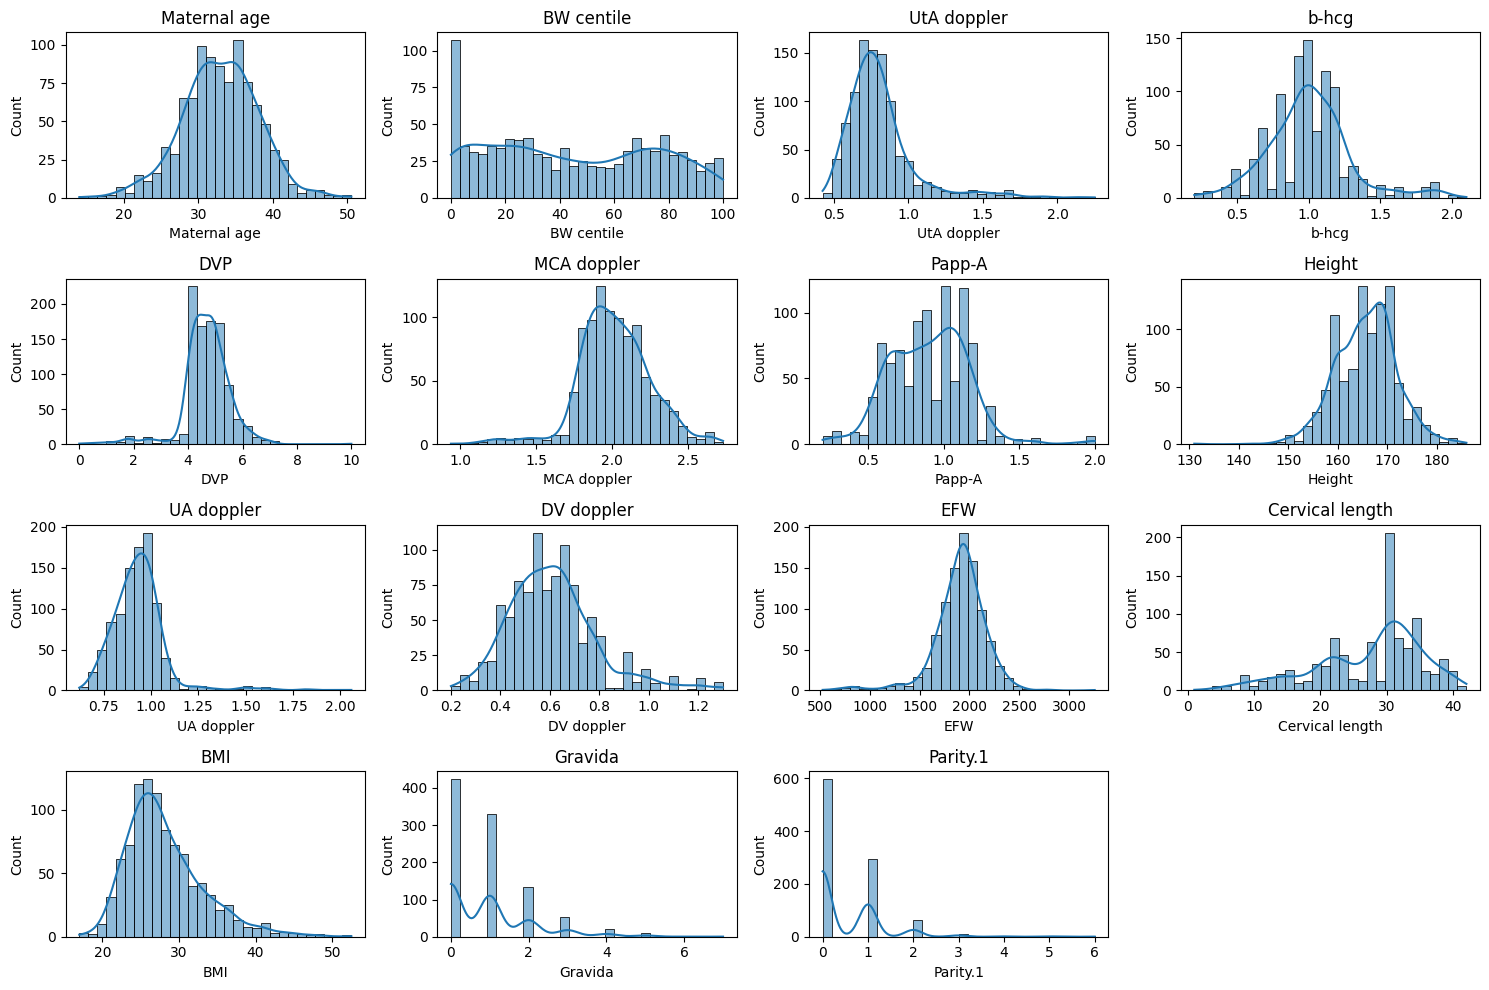

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Συνεχείς μεταβλητές
continuous_vars = ['Maternal age', 'BW centile', 'UtA doppler', 'b-hcg', 'DVP', 'MCA doppler',
                   'Papp-A', 'Height', 'UA doppler', 'DV doppler', 'EFW', 'Cervical length', 'BMI', 'Gravida', 'Parity.1']

# Ιστόγραμμα για κάθε συνεχή μεταβλητή
plt.figure(figsize=(15, 10))
for i, var in enumerate(continuous_vars):
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[var], bins=30, kde=True)
    plt.title(var)

plt.tight_layout()
plt.show()

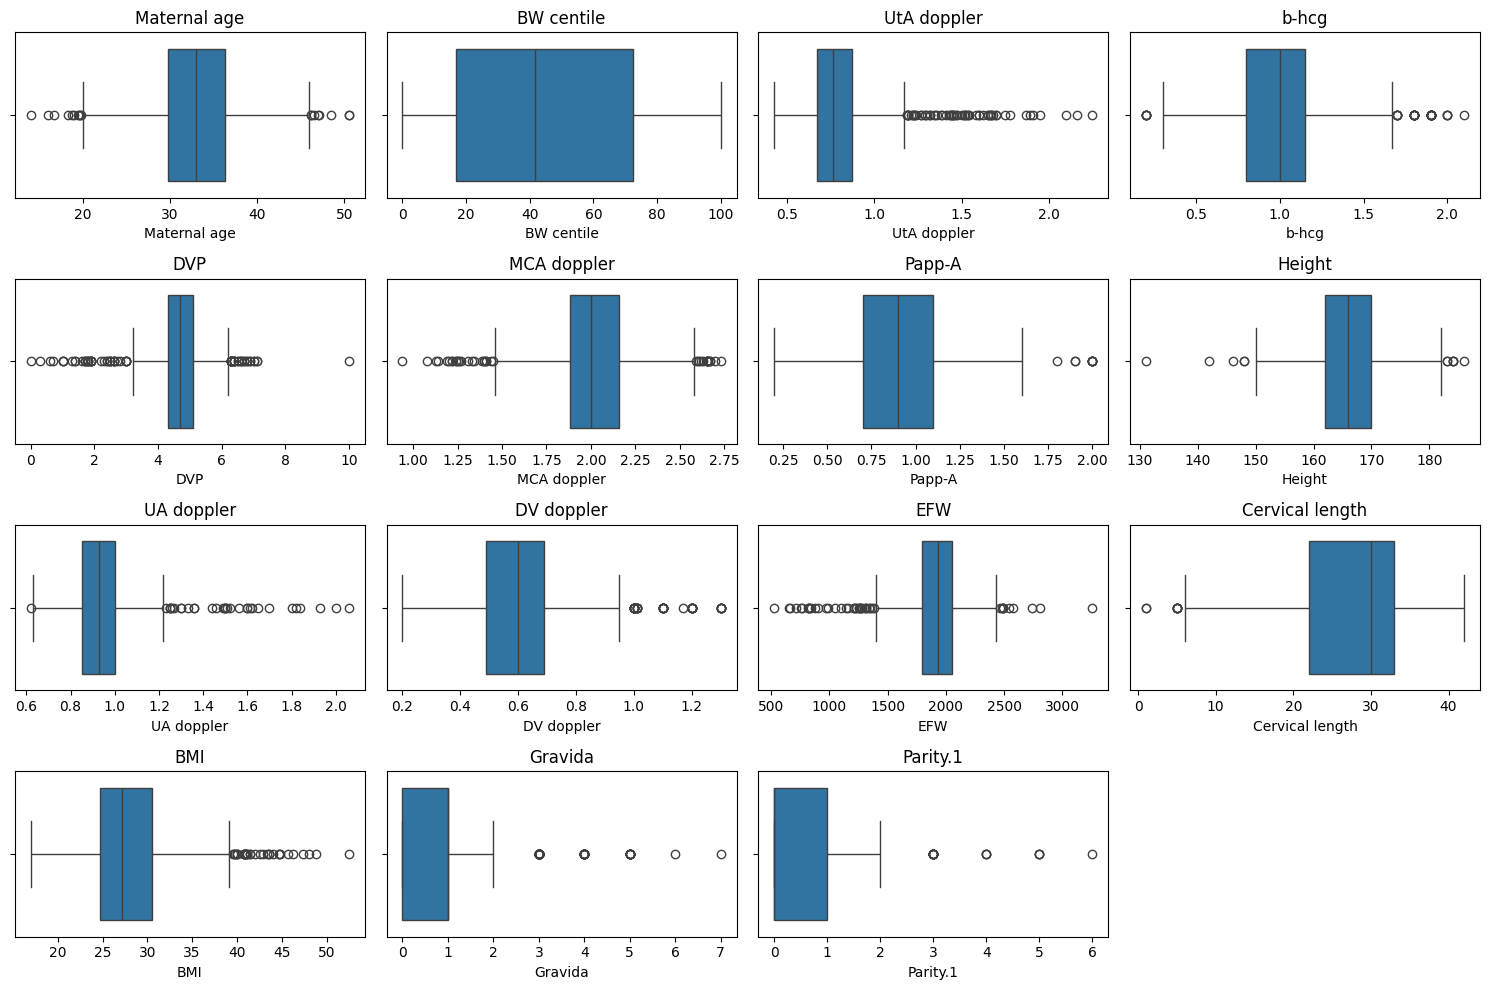

In [4]:
plt.figure(figsize=(15, 10))
for i, var in enumerate(continuous_vars):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=df[var])
    plt.title(var)

plt.tight_layout()
plt.show()

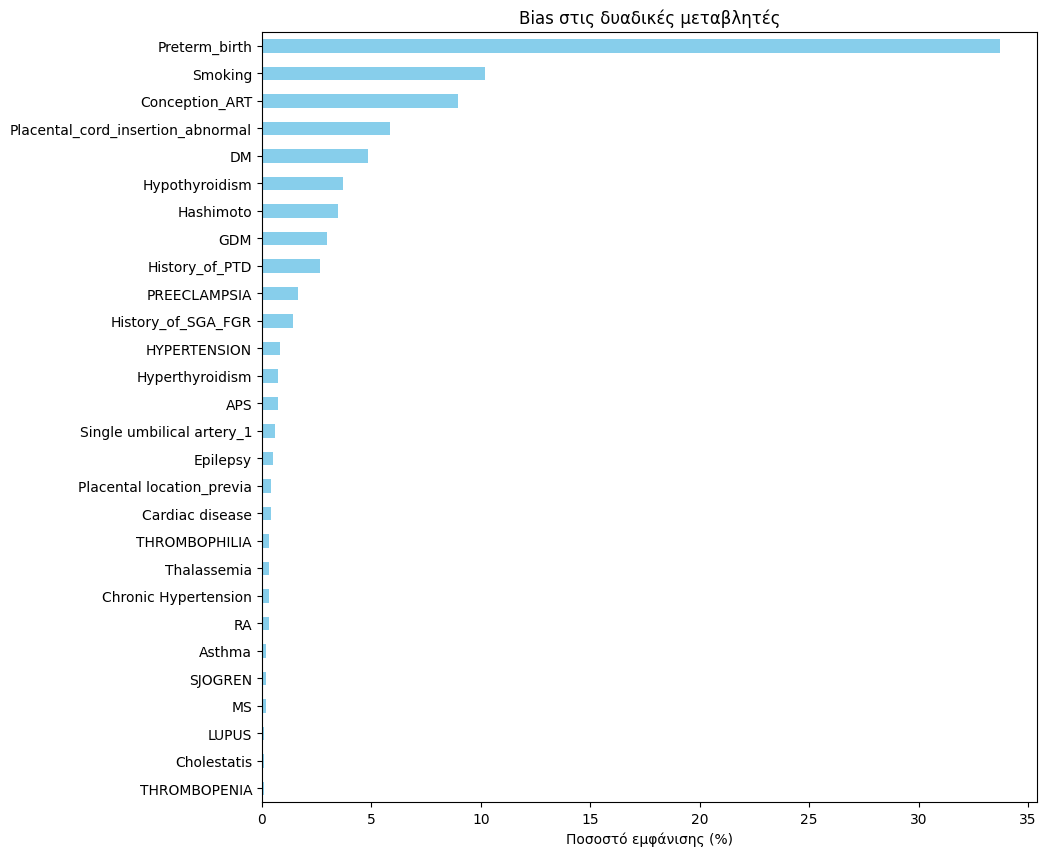

In [5]:
# Δυαδικές μεταβλητές
binary_vars = ['Smoking', 'Conception_ART', 'History_of_SGA_FGR', 'History_of_PTD', 'Preterm_birth',
               'Placental_cord_insertion_abnormal', 'GDM', 'PREECLAMPSIA', 'DM', 'Epilepsy',
               'Cholestatis', 'Hypothyroidism', 'Thalassemia', 'Hyperthyroidism', 'THROMBOPHILIA',
               'Hashimoto', 'LUPUS', 'APS', 'HYPERTENSION', 'Chronic Hypertension', 'THROMBOPENIA',
               'RA', 'Cardiac disease', 'Asthma', 'SJOGREN', 'MS', 'Placental location_previa',
               'Single umbilical artery_1']

# Υπολογισμός ποσοστών για κάθε δυαδική μεταβλητή
binary_bias = df[binary_vars].mean() * 100  # Μετατροπή σε ποσοστά %

# Οπτικοποίηση
plt.figure(figsize=(10, 10))
binary_bias.sort_values().plot(kind='barh', color='skyblue')
plt.xlabel("Ποσοστό εμφάνισης (%)")
plt.title("Bias στις δυαδικές μεταβλητές")
plt.show()

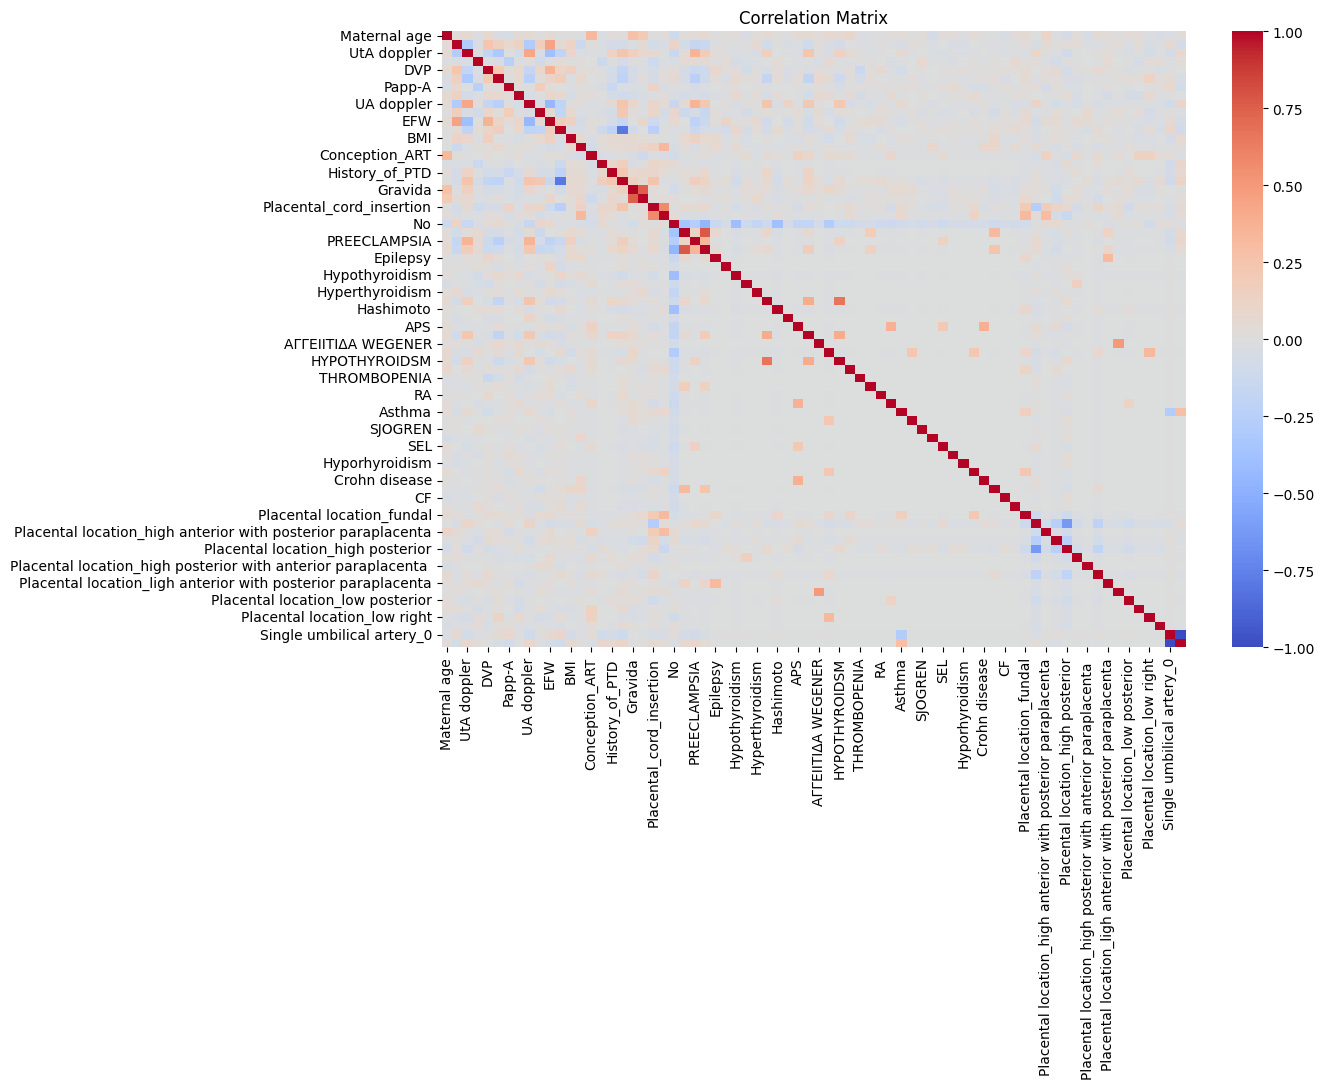

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

In [7]:
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

# Έλεγχος διαφοράς ηλικίας μεταξύ γυναικών που γέννησαν πρόωρα και που γέννησαν φυσιολογικά
preterm_birth_yes = df[df['Preterm_birth'] == 1]['Maternal age']
preterm_birth_no = df[df['Preterm_birth'] == 0]['Maternal age']

# Δοκιμή και για έλεγχο χωρίς να είναι απαραίτητη η κανονική κατανομή του δείγματος
u_stat, p_mw = mannwhitneyu(preterm_birth_yes, preterm_birth_no)
print(f"Mann-Whitney U test: U-stat={u_stat:.3f}, p-value={p_mw:.3f}")

t_stat, p_value = ttest_ind(preterm_birth_yes, preterm_birth_no, equal_var=False)

print(f"T-test για ηλικία και πρόωρο τοκετό: t-stat={t_stat:.3f}, p-value={p_value:.3f}")

Mann-Whitney U test: U-stat=106900.000, p-value=0.787
T-test για ηλικία και πρόωρο τοκετό: t-stat=0.327, p-value=0.744


In [8]:
from scipy.stats import ttest_ind

# Έλεγχος διαφοράς μήκους τραχήλου της μήτρας μεταξύ γυναικών που γέννησαν πρόωρα και που γέννησαν φυσιολογικά
cervical_length_yes = df[df['Cervical length'] == 1]['Preterm_birth']
cervical_length_no = df[df['Cervical length'] == 0]['Preterm_birth']

t_stat, p_value = ttest_ind(cervical_length_yes, cervical_length_no, equal_var=False)

print(f"T-test για μήκος τραχήλου μήτρας και πρόωρο τοκετό: t-stat={t_stat:.3f}, p-value={p_value:.3f}")

#Προκύπτει το συμπέρασμα ότι οι τιμές του dataset δεν είναι καλά κατανεμημένες

T-test για μήκος τραχήλου μήτρας και πρόωρο τοκετό: t-stat=nan, p-value=nan


In [9]:
from scipy.stats import ttest_ind

# Έλεγχος διαφοράς για πρόωρο τοκετό μεταξύ γυναικών με και χωρίς προεκλαμψία
pre_eclampsia_yes = df[df['PREECLAMPSIA'] == 1]['Preterm_birth']
pre_eclampsia_no = df[df['PREECLAMPSIA'] == 0]['Preterm_birth']

t_stat, p_value = ttest_ind(pre_eclampsia_yes, pre_eclampsia_no, equal_var=False)

print(f"T-test για πρόωρο τοκετό και προεκλαμψία: t-stat={t_stat:.3f}, p-value={p_value:.3f}")

T-test για πρόωρο τοκετό και προεκλαμψία: t-stat=9.491, p-value=0.000


In [15]:
from scipy.stats import ttest_ind

# Έλεγχος διαφοράς για πρόωρο τοκετό μεταξύ γυναικών με και χωρίς διαβήτη
dm_yes = df[df['DM'] == 1]['Preterm_birth']
dm_no = df[df['DM'] == 0]['Preterm_birth']

t_stat, p_value = ttest_ind(dm_yes, dm_no, equal_var=False)

print(f"T-test για πρόωρο τοκετό και διαβήτη: t-stat={t_stat:.3f}, p-value={p_value:.3f}")

T-test για πρόωρο τοκετό και διαβήτη: t-stat=3.674, p-value=0.001


In [17]:
from scipy.stats import ttest_ind

# Έλεγχος διαφοράς για Papp-A μεταξύ γυναικών που γέννησαν πρόωρα και που γέννησαν φυσιολογικά
papp_a_yes = df[df['Papp-A'] == 1]['Preterm_birth']
papp_a_no = df[df['Papp-A'] == 0]['Preterm_birth']

t_stat, p_value = ttest_ind(papp_a_yes, papp_a_no, equal_var=False)

print(f"T-test για πρόωρο τοκετό και Papp-A: t-stat={t_stat:.3f}, p-value={p_value:.3f}")

T-test για πρόωρο τοκετό και Papp-A: t-stat=nan, p-value=nan


In [10]:
from scipy.stats import chi2_contingency

# Δημιουργία πίνακα συχνοτήτων
contingency_table = pd.crosstab(df['Smoking'], df['Preterm_birth'])

# Χ² test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Χ² test για κάπνισμα και πρόωρο τοκετό: Χ²={chi2:.3f}, p-value={p_value:.3f}")

Χ² test για κάπνισμα και πρόωρο τοκετό: Χ²=2.556, p-value=0.110


In [11]:
from scipy.stats import chi2_contingency

# Δημιουργία πίνακα συχνοτήτων
contingency_table = pd.crosstab(df['Conception_ART'], df['Preterm_birth'])

# Χ² test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Χ² test για εξωσωματική και πρόωρο τοκετό: Χ²={chi2:.3f}, p-value={p_value:.3f}")

Χ² test για εξωσωματική και πρόωρο τοκετό: Χ²=0.002, p-value=0.967


In [12]:
from scipy.stats import chi2_contingency

# Δημιουργία πίνακα συχνοτήτων
contingency_table = pd.crosstab(df['History_of_PTD'], df['Preterm_birth'])

# Χ² test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Χ² test για ιστορικό πρόωρου τοκετού και πρόωρο τοκετό: Χ²={chi2:.3f}, p-value={p_value:.3f}")

Χ² test για ιστορικό πρόωρου τοκετού και πρόωρο τοκετό: Χ²=49.528, p-value=0.000


In [13]:
from scipy.stats import chi2_contingency

# Δημιουργία πίνακα συχνοτήτων
contingency_table = pd.crosstab(df['Placental_cord_insertion_abnormal'], df['Preterm_birth'])

# Χ² test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Χ² test για μη φυσιολογική θέση πλακούντα και πρόωρο τοκετό: Χ²={chi2:.3f}, p-value={p_value:.3f}")

Χ² test για μη φυσιολογική θέση πλακούντα και πρόωρο τοκετό: Χ²=0.245, p-value=0.620
